In [23]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Feature selection libraries
from sklearn.feature_selection import VarianceThreshold, mutual_info_regression
from sklearn.feature_selection import RFE, SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Additional libraries for saving
import json
import pickle
from datetime import datetime

In [24]:
# LOAD MASTER DATASET
try:
    # Load your master dataset
    master_df = pd.read_csv('../data/relationship/master_relationship_table.csv') 
    
    print("="*60)
    print("LOADING DATASET")
    print("="*60)
    print("Original Dataset Shape:", master_df.shape)
    print("\nColumns:", master_df.columns.tolist())
    print("\nFirst 5 rows:")
    print(master_df.head())
    
    # Ensure Year is integer
    master_df['Year'] = master_df['Year'].astype(int)
    print("\n✅ Dataset loaded successfully!")
    
except FileNotFoundError:
    print("❌ ERROR: 'master_dataset.csv' not found. Please check the file path.")
    raise
except Exception as e:
    print(f"❌ ERROR loading dataset: {str(e)}")
    raise


LOADING DATASET
Original Dataset Shape: (288, 15)

Columns: ['Year', 'Category', 'Spending_Lowest_20', 'Spending_Second_20', 'Spending_Middle_20', 'Spending_Fourth_20', 'Spending_Highest_20', 'Crude_Oil_Price_USD', 'Petrol_Price_pence_per_litre', 'Diesel_Price_pence_per_litre', 'CPI_Fuels_and_Lubricants', 'CPI_Electricity', 'CPI_Gas', 'CPI_Liquid_Fuels', 'CPI_Solid_Fuels']

First 5 rows:
   Year          Category  Spending_Lowest_20  Spending_Second_20  \
0  2020  Alcoholic drinks                4.10                5.44   
1  2021  Alcoholic drinks                4.65                6.50   
2  2022  Alcoholic drinks                4.61                6.81   
3  2023  Alcoholic drinks                4.74                6.78   
4  2024  Alcoholic drinks                4.94                7.16   

   Spending_Middle_20  Spending_Fourth_20  Spending_Highest_20  \
0                7.63                9.73                14.92   
1                8.59               11.17                16.90

# FEATURE ENGINEERING

In [25]:
def engineer_features(df):
    try:
        df_fe = df.copy()
        
        
        # TEMPORAL FEATURES
        
        
        # Basic temporal (year already exists)
        df_fe['Year'] = df_fe['Year'].astype(int)
        
        # Create time trends
        df_fe['Time_Trend'] = df_fe['Year'] - 2019  # Starts at 1 for 2020
        
        # Crisis period indicators
        df_fe['Energy_Crisis'] = df_fe['Year'].apply(lambda x: 1 if x >= 2022 else 0)
        df_fe['Post_COVID'] = df_fe['Year'].apply(lambda x: 1 if x >= 2021 else 0)
        df_fe['Ukraine_War'] = df_fe['Year'].apply(lambda x: 1 if x >= 2022 else 0)
        
        
        # NUMERICAL FEATURES - CRUDE OIL
        
        
        # Lagged crude oil prices (yearly lags)
        df_fe['Crude_Lag1'] = df_fe.groupby('Category')['Crude_Oil_Price_USD'].shift(1)
        df_fe['Crude_Lag2'] = df_fe.groupby('Category')['Crude_Oil_Price_USD'].shift(2)
        df_fe['Crude_Lag3'] = df_fe.groupby('Category')['Crude_Oil_Price_USD'].shift(3)
        
        # Year-over-year changes
        df_fe['Crude_YoY_Change'] = df_fe.groupby('Category')['Crude_Oil_Price_USD'].pct_change() * 100
        df_fe['Crude_YoY_Change'] = df_fe['Crude_YoY_Change'].fillna(0)
        
        # Rolling statistics (2-year and 3-year rolling)
        df_fe['Crude_Rolling_Mean_2Y'] = df_fe.groupby('Category')['Crude_Oil_Price_USD'].transform(
            lambda x: x.rolling(2, min_periods=1).mean()
        )
        df_fe['Crude_Rolling_Mean_3Y'] = df_fe.groupby('Category')['Crude_Oil_Price_USD'].transform(
            lambda x: x.rolling(3, min_periods=1).mean()
        )
        df_fe['Crude_Rolling_Std_2Y'] = df_fe.groupby('Category')['Crude_Oil_Price_USD'].transform(
            lambda x: x.rolling(2, min_periods=1).std()
        )
        df_fe['Crude_Rolling_Std_3Y'] = df_fe.groupby('Category')['Crude_Oil_Price_USD'].transform(
            lambda x: x.rolling(3, min_periods=1).std()
        )
        
        # Volatility indicators
        df_fe['Crude_Volatility'] = df_fe['Crude_Rolling_Std_2Y'] / df_fe['Crude_Rolling_Mean_2Y']
        df_fe['Crude_Volatility'] = df_fe['Crude_Volatility'].fillna(0)
        
        # Shock indicators
        df_fe['Oil_Price_Shock'] = df_fe['Crude_YoY_Change'].apply(
            lambda x: 1 if x > 20 else 0  # >20% increase is a shock
        )
        df_fe['Oil_Price_Decline'] = df_fe['Crude_YoY_Change'].apply(
            lambda x: 1 if x < -15 else 0  # >15% decrease
        )
        
        
        # NUMERICAL FEATURES - PETROL & DIESEL
        
        
        # Petrol and Diesel lags
        df_fe['Petrol_Lag1'] = df_fe.groupby('Category')['Petrol_Price_pence_per_litre'].shift(1)
        df_fe['Diesel_Lag1'] = df_fe.groupby('Category')['Diesel_Price_pence_per_litre'].shift(1)
        
        # Petrol/Diesel spread
        df_fe['Fuel_Spread'] = df_fe['Diesel_Price_pence_per_litre'] - df_fe['Petrol_Price_pence_per_litre']
        
        # Pass-through rate (pump price vs crude oil price)
        df_fe['Petrol_Pass_Through'] = df_fe['Petrol_Price_pence_per_litre'] / df_fe['Crude_Oil_Price_USD']
        df_fe['Diesel_Pass_Through'] = df_fe['Diesel_Price_pence_per_litre'] / df_fe['Crude_Oil_Price_USD']
        
        # Fuel price YoY changes
        df_fe['Petrol_YoY'] = df_fe.groupby('Category')['Petrol_Price_pence_per_litre'].pct_change() * 100
        df_fe['Petrol_YoY'] = df_fe['Petrol_YoY'].fillna(0)
        df_fe['Diesel_YoY'] = df_fe.groupby('Category')['Diesel_Price_pence_per_litre'].pct_change() * 100
        df_fe['Diesel_YoY'] = df_fe['Diesel_YoY'].fillna(0)
        
        
        # NUMERICAL FEATURES - CPI ENERGY COMPONENTS
        
        
        # Energy basket average
        energy_cols = ['CPI_Electricity', 'CPI_Gas', 'CPI_Liquid_Fuels', 'CPI_Solid_Fuels']
        df_fe['CPI_Energy_Basket'] = df_fe[energy_cols].mean(axis=1)
        
        # Energy price volatility across components
        df_fe['CPI_Energy_Std'] = df_fe[energy_cols].std(axis=1)
        
        # Component ratios (captures substitution effects)
        df_fe['CPI_Gas_Electricity_Ratio'] = df_fe['CPI_Gas'] / df_fe['CPI_Electricity']
        
        
        # NUMERICAL FEATURES - SPENDING TRANSFORMATIONS
        
        
        # Quintile spending ratios (inequality metrics)
        df_fe['Lowest_Highest_Ratio'] = df_fe['Spending_Lowest_20'] / df_fe['Spending_Highest_20']
        df_fe['Middle_Highest_Ratio'] = df_fe['Spending_Middle_20'] / df_fe['Spending_Highest_20']
        
        # Quintile spending gaps
        df_fe['Lowest_Highest_Gap'] = df_fe['Spending_Highest_20'] - df_fe['Spending_Lowest_20']
        df_fe['Middle_Highest_Gap'] = df_fe['Spending_Highest_20'] - df_fe['Spending_Middle_20']
        
        # Quintile spending YoY changes
        for quintile in ['Lowest_20', 'Second_20', 'Middle_20', 'Fourth_20', 'Highest_20']:
            col_name = f'Spending_{quintile}'
            yoy_col = f'{col_name}_YoY'
            df_fe[yoy_col] = df_fe.groupby('Category')[col_name].pct_change() * 100
            df_fe[yoy_col] = df_fe[yoy_col].fillna(0)
        
        
        # DOMAIN-SPECIFIC FEATURES
        
        
        # Category classification
        def classify_category(category):
            
            energy_categories = ['Electricity', 'Gas', 'Other fuels']
            transport_categories = ['Petrol, diesel and oils', 'Vehicle purchase', 
                                   'Vehicle repairs', 'Public transport']
            necessities = ['Food', 'Bread, rice and cereals', 'Milk and dairy', 
                          'Vegetables', 'Fruit', 'Fish', 'Poultry', 'Beef',
                          'Water supply', 'Housing (net)']
            
            if category in energy_categories:
                return 'Energy'
            elif category in transport_categories:
                return 'Transport'
            elif category in necessities:
                return 'Necessity'
            else:
                return 'Discretionary'
        
        df_fe['Category_Type'] = df_fe['Category'].apply(classify_category)
        
        # Category sensitivity score (domain knowledge based)
        def get_sensitivity_score(category):
            
            high_sensitivity = ['Electricity', 'Gas', 'Other fuels', 'Petrol, diesel and oils']
            medium_sensitivity = ['Public transport', 'Vehicle purchase', 'Vehicle repairs', 
                                 'Food', 'Housing (net)']
            
            if category in high_sensitivity:
                return 'High'
            elif category in medium_sensitivity:
                return 'Medium'
            else:
                return 'Low'
        
        df_fe['Sensitivity_Level'] = df_fe['Category'].apply(get_sensitivity_score)
        
        # Winter heating dependency
        winter_categories = ['Electricity', 'Gas', 'Other fuels', 'Housing (net)']
        df_fe['Winter_Heating_Dependency'] = df_fe['Category'].apply(
            lambda x: 1 if x in winter_categories else 0
        )
        
        # Regressive impact score (theoretical)
        def regressive_score(category, year):
            
            if category in ['Electricity', 'Gas', 'Other fuels']:
                return 3  # Highest regressive impact
            elif category in ['Petrol, diesel and oils', 'Public transport']:
                return 2
            elif category in ['Food', 'Housing (net)']:
                return 1.5
            else:
                return 1
        
        df_fe['Regressive_Score'] = df_fe.apply(
            lambda row: regressive_score(row['Category'], row['Year']), axis=1
        )
        
        
        # INTERACTION FEATURES (CRITICAL FOR YOUR RESEARCH QUESTION)
        
        
        # Oil × Year (changing sensitivity over time)
        df_fe['Oil_Year_Interaction'] = df_fe['Crude_Oil_Price_USD'] * df_fe['Time_Trend']
        
        # Oil × Crisis
        df_fe['Oil_Crisis_Interaction'] = df_fe['Crude_Oil_Price_USD'] * df_fe['Energy_Crisis']
        
        # Oil × Category_Type (differential impact by category)
        # Create dummy variables for Category_Type and multiply
        category_dummies = pd.get_dummies(df_fe['Category_Type'], prefix='Cat')
        for cat_type in category_dummies.columns:
            df_fe[f'Oil_{cat_type}'] = df_fe['Crude_Oil_Price_USD'] * category_dummies[cat_type]
        
        # Petrol × Winter (seasonal demand)
        df_fe['Petrol_Winter_Interaction'] = df_fe['Petrol_Price_pence_per_litre'] * df_fe['Winter_Heating_Dependency']
        
        # Energy CPI × Winter
        df_fe['Energy_CPI_Winter'] = df_fe['CPI_Energy_Basket'] * df_fe['Winter_Heating_Dependency']
        
        
        # HANDLE INFINITE AND NaN VALUES
        
        
        # Replace inf with NaN then fill with 0
        df_fe = df_fe.replace([np.inf, -np.inf], np.nan)
        
        # Fill remaining NaNs with 0 (for features where it makes sense)
        df_fe = df_fe.fillna(0)
        
        return df_fe
        
    except Exception as e:
        print(f"❌ ERROR in feature engineering: {str(e)}")
        raise

In [26]:
# Apply feature engineering
try:
    print("\n" + "="*60)
    print("FEATURE ENGINEERING")
    print("="*60)
    
    master_fe = engineer_features(master_df)
    
    print(f"\n✅ Feature engineering complete!")
    print(f"New dataset shape: {master_fe.shape}")
    print(f"Number of features: {master_fe.shape[1]}")
    print("\nNew features created:")
    new_features = [col for col in master_fe.columns if col not in master_df.columns]
    print(f"Added {len(new_features)} new features")
    print("\nSample of new features:")
    print(new_features[:20])
    
except Exception as e:
    print(f"❌ ERROR in feature engineering step: {str(e)}")
    raise


FEATURE ENGINEERING

✅ Feature engineering complete!
New dataset shape: (288, 61)
Number of features: 61

New features created:
Added 46 new features

Sample of new features:
['Time_Trend', 'Energy_Crisis', 'Post_COVID', 'Ukraine_War', 'Crude_Lag1', 'Crude_Lag2', 'Crude_Lag3', 'Crude_YoY_Change', 'Crude_Rolling_Mean_2Y', 'Crude_Rolling_Mean_3Y', 'Crude_Rolling_Std_2Y', 'Crude_Rolling_Std_3Y', 'Crude_Volatility', 'Oil_Price_Shock', 'Oil_Price_Decline', 'Petrol_Lag1', 'Diesel_Lag1', 'Fuel_Spread', 'Petrol_Pass_Through', 'Diesel_Pass_Through']


# PREPARE DATA FOR FEATURE SELECTION (WITH ERROR HANDLING)

In [27]:
try:
    print("\n" + "="*60)
    print("DATA PREPARATION")
    print("="*60)
    
    # Define target variables (spending for low and middle income)
    target_cols = ['Spending_Lowest_20', 'Spending_Middle_20']
    
    # Define feature columns (exclude non-predictive columns)
    exclude_cols = ['Year', 'Category'] + target_cols
    feature_cols = [col for col in master_fe.columns if col not in exclude_cols]
    
    # Create feature matrix and target vectors
    X = master_fe[feature_cols]
    y_low = master_fe['Spending_Lowest_20']
    y_mid = master_fe['Spending_Middle_20']
    
    # Convert categorical columns to numeric using one-hot encoding
    categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
    if categorical_cols:
        print(f"Converting categorical columns: {categorical_cols}")
        X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
    
    print(f"\nFeature matrix shape: {X.shape}")
    print(f"Number of features for selection: {len(X.columns)}")
    print("✅ Data prepared successfully!")
    
except Exception as e:
    print(f"❌ ERROR in data preparation: {str(e)}")
    raise


DATA PREPARATION
Converting categorical columns: ['Category_Type', 'Sensitivity_Level']

Feature matrix shape: (288, 60)
Number of features for selection: 60
✅ Data prepared successfully!


# FEATURE SELECTION (WITH ERROR HANDLING)

In [28]:
class FeatureSelector:
  
    
    def __init__(self, X, y_low, y_mid):
        self.X = X
        self.y_low = y_low
        self.y_mid = y_mid
        self.feature_names = X.columns.tolist()
        self.selected_features = {}
        self.errors = {}
        self.warnings = []
        self.selection_results = {}
        
    def correlation_analysis(self):
        
        print("\n" + "="*60)
        print("CORRELATION ANALYSIS")
        print("="*60)
        
        try:
            # Correlation with targets
            corr_low = self.X.corrwith(self.y_low).sort_values(ascending=False)
            corr_mid = self.X.corrwith(self.y_mid).sort_values(ascending=False)
            
            # Store results
            self.selection_results['correlation_low'] = corr_low.head(20).to_dict()
            self.selection_results['correlation_mid'] = corr_mid.head(20).to_dict()
            
            # Top 10 most correlated features for each target
            print("\nTop 10 features correlated with Lowest_20 spending:")
            print(corr_low.head(10))
            
            print("\nTop 10 features correlated with Middle_20 spending:")
            print(corr_mid.head(10))
            
            # Correlation matrix heatmap (top features only)
            top_features = list(corr_low.head(15).index) + list(corr_mid.head(15).index)
            top_features = list(set(top_features))  # Remove duplicates
            
            if len(top_features) > 1:
                plt.figure(figsize=(12, 10))
                corr_matrix = self.X[top_features].corr()
                sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                           center=0, square=True, linewidths=0.5)
                plt.title('Correlation Matrix of Top Features')
                plt.tight_layout()
                plt.savefig('../data/features/correlation_matrix.png')
                plt.show()
                print("📊 Correlation heatmap saved as 'correlation_matrix.png'")
            
            # Identify highly correlated features (multicollinearity)
            corr_matrix_full = self.X.corr().abs()
            upper_tri = corr_matrix_full.where(np.triu(np.ones(corr_matrix_full.shape), k=1).astype(bool))
            high_corr_features = [column for column in upper_tri.columns if any(upper_tri[column] > 0.8)]
            
            print(f"\nFeatures with high multicollinearity (corr > 0.8):")
            print(f"Count: {len(high_corr_features)}")
            if high_corr_features:
                print("Examples:", high_corr_features[:10])
                self.selection_results['high_correlation_features'] = high_corr_features
            
            return high_corr_features
            
        except Exception as e:
            error_msg = f"Error in correlation analysis: {str(e)}"
            print(f"⚠️ {error_msg}")
            self.errors['correlation_analysis'] = error_msg
            return []
    
    def variance_filter(self, threshold=0.01):
        
        print("\n" + "="*60)
        print("VARIANCE FILTER")
        print("="*60)
        
        try:
            # Standardize features first
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(self.X)
            
            # Apply variance threshold
            selector = VarianceThreshold(threshold=threshold)
            X_selected = selector.fit_transform(X_scaled)
            
            # Get selected feature names
            selected_mask = selector.get_support()
            selected_features = self.X.columns[selected_mask].tolist()
            removed_features = self.X.columns[~selected_mask].tolist()
            
            self.selection_results['variance_selected'] = selected_features
            self.selection_results['variance_removed'] = removed_features[:20]
            
            print(f"Features kept: {len(selected_features)}")
            print(f"Features removed: {len(removed_features)}")
            print("\nRemoved features (low variance):")
            print(removed_features[:10])
            
            return selected_features
            
        except Exception as e:
            error_msg = f"Error in variance filter: {str(e)}"
            print(f"⚠️ {error_msg}")
            self.errors['variance_filter'] = error_msg
            return self.X.columns.tolist()  # Return all features if error
    
    def mutual_information(self, target, target_name, k=20):
        
        print("\n" + "="*60)
        print(f"MUTUAL INFORMATION SELECTION ({target_name})")
        print("="*60)
        
        try:
            # Fill any remaining NaNs
            X_clean = self.X.fillna(0)
            
            # Calculate MI scores
            mi_scores = mutual_info_regression(X_clean, target, random_state=42)
            mi_series = pd.Series(mi_scores, index=self.feature_names).sort_values(ascending=False)
            
            # Select top k features
            top_features = mi_series.head(k).index.tolist()
            
            print(f"Top {k} features by Mutual Information:")
            print(mi_series.head(k))
            
            # Store results
            self.selection_results[f'mutual_info_{target_name}'] = mi_series.head(20).to_dict()
            
            return top_features, mi_series
            
        except Exception as e:
            error_msg = f"Error in mutual information: {str(e)}"
            print(f"⚠️ {error_msg}")
            self.errors[f'mutual_info_{target_name}'] = error_msg
            return [], pd.Series()
    
    def rfe_selection(self, target, target_name, n_features=15):
        
        print("\n" + "="*60)
        print(f"STEP 4.4: RECURSIVE FEATURE ELIMINATION ({target_name})")
        print("="*60)
        
        try:
            # Fill NaNs
            X_clean = self.X.fillna(0)
            
            # Use Random Forest as estimator
            estimator = RandomForestRegressor(n_estimators=100, random_state=42)
            rfe = RFE(estimator, n_features_to_select=n_features, step=5)
            rfe.fit(X_clean, target)
            
            # Get selected features
            selected_mask = rfe.support_
            selected_features = X_clean.columns[selected_mask].tolist()
            
            print(f"RFE selected {len(selected_features)} features:")
            print(selected_features)
            
            # Store results
            self.selection_results[f'rfe_{target_name}'] = selected_features
            
            return selected_features
            
        except Exception as e:
            error_msg = f"Error in RFE: {str(e)}"
            print(f"⚠️ {error_msg}")
            self.errors[f'rfe_{target_name}'] = error_msg
            return []
    
    def embedded_selection(self, target, target_name):
        
        print("\n" + "="*60)
        print(f"STEP 4.5: EMBEDDED METHODS ({target_name})")
        print("="*60)
        
        try:
            # Fill NaNs
            X_clean = self.X.fillna(0)
            
            # 5.1 Random Forest
            rf = RandomForestRegressor(n_estimators=200, random_state=42)
            rf.fit(X_clean, target)
            rf_importance = pd.Series(rf.feature_importances_, index=self.feature_names).sort_values(ascending=False)
            
            print("\nTop 15 features - Random Forest:")
            print(rf_importance.head(15))
            
            # 5.2 Gradient Boosting
            gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
            gb.fit(X_clean, target)
            gb_importance = pd.Series(gb.feature_importances_, index=self.feature_names).sort_values(ascending=False)
            
            print("\nTop 15 features - Gradient Boosting:")
            print(gb_importance.head(15))
            
            # 5.3 Lasso for feature selection
            lasso = LassoCV(cv=5, random_state=42)
            lasso.fit(X_clean, target)
            
            # Get non-zero coefficients
            lasso_selected = [self.feature_names[i] for i, coef in enumerate(lasso.coef_) if abs(coef) > 1e-6]
            
            print(f"\nLasso selected {len(lasso_selected)} features (non-zero coefficients):")
            print(lasso_selected[:10])
            
            # Store results
            self.selection_results[f'rf_importance_{target_name}'] = rf_importance.head(20).to_dict()
            self.selection_results[f'gb_importance_{target_name}'] = gb_importance.head(20).to_dict()
            self.selection_results[f'lasso_selected_{target_name}'] = lasso_selected
            
            return rf_importance, gb_importance, lasso_selected
            
        except Exception as e:
            error_msg = f"Error in embedded selection: {str(e)}"
            print(f"⚠️ {error_msg}")
            self.errors[f'embedded_{target_name}'] = error_msg
            return pd.Series(), pd.Series(), []
    
    def run_full_selection(self, target_name, target):
        
        print(f"\n{'#'*60}")
        print(f"FEATURE SELECTION FOR: {target_name}")
        print(f"{'#'*60}")
        
        try:
            # Run all selection methods
            high_corr = self.correlation_analysis()
            variance_selected = self.variance_filter()
            mi_top, mi_scores = self.mutual_information(target, target_name, k=20)
            rfe_selected = self.rfe_selection(target, target_name, n_features=15)
            rf_imp, gb_imp, lasso_selected = self.embedded_selection(target, target_name)
            
            # Combine results
            consensus_features = list(set(
                variance_selected[:20] + 
                mi_top[:15] + 
                rfe_selected + 
                lasso_selected[:15]
            ))
            
            # Further filter by domain knowledge
            domain_essential = [
                'Crude_Oil_Price_USD',
                'Petrol_Price_pence_per_litre',
                'Diesel_Price_pence_per_litre',
                'CPI_Energy_Basket',
                'Lowest_Highest_Ratio'
            ]
            
            final_features = list(set(consensus_features + domain_essential))
            
            print(f"\n{'='*60}")
            print(f"FINAL SELECTED FEATURES FOR {target_name}: {len(final_features)}")
            print("="*60)
            print(final_features)
            
            # Save to dictionary
            self.selected_features[target_name] = final_features
            self.selection_results[f'final_features_{target_name}'] = final_features
            
            return final_features
            
        except Exception as e:
            error_msg = f"Error in full selection for {target_name}: {str(e)}"
            print(f"❌ {error_msg}")
            self.errors[f'full_selection_{target_name}'] = error_msg
            # Return essential features as fallback
            return ['Crude_Oil_Price_USD', 'Petrol_Price_pence_per_litre', 
                   'Diesel_Price_pence_per_litre', 'CPI_Energy_Basket', 
                   'Lowest_Highest_Ratio']

# Initialize feature selector
selector = FeatureSelector(X, y_low, y_mid)



FEATURE SELECTION

############################################################
FEATURE SELECTION FOR: Spending_Lowest_20
############################################################

CORRELATION ANALYSIS

Top 10 features correlated with Lowest_20 spending:
Spending_Second_20          0.980733
Lowest_Highest_Ratio        0.930894
Middle_Highest_Ratio        0.914603
Spending_Fourth_20          0.892264
Spending_Highest_20         0.812334
Sensitivity_Level_Medium    0.652108
Lowest_Highest_Gap          0.329993
Category_Type_Transport     0.268778
Oil_Cat_Transport           0.256462
Regressive_Score            0.211084
dtype: float64

Top 10 features correlated with Middle_20 spending:
Spending_Fourth_20          0.987381
Spending_Second_20          0.984708
Spending_Highest_20         0.926003
Middle_Highest_Ratio        0.904130
Lowest_Highest_Ratio        0.773874
Lowest_Highest_Gap          0.572967
Sensitivity_Level_Medium    0.564991
Category_Type_Transport     0.380836
Oil_Cat

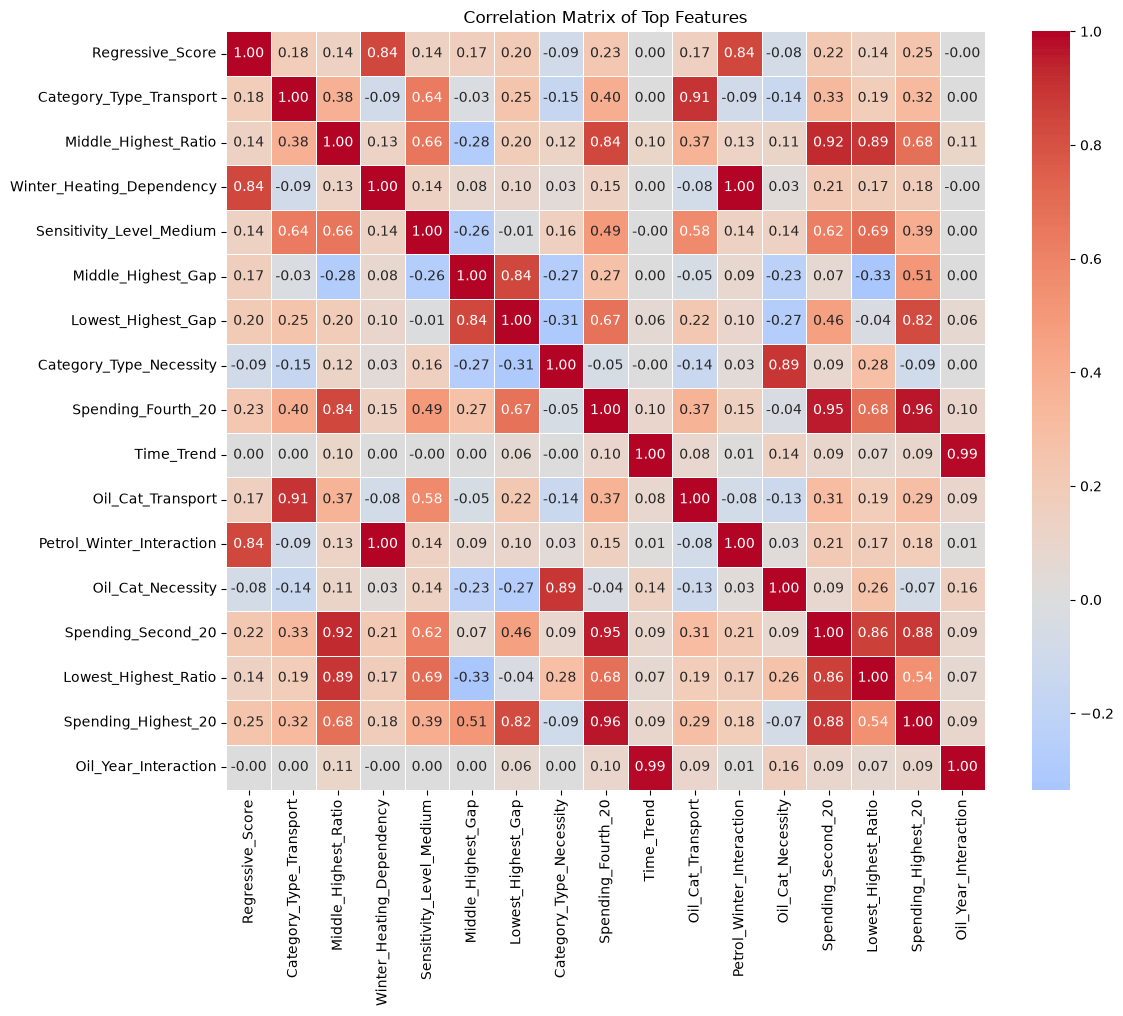

📊 Correlation heatmap saved as 'correlation_matrix.png'

Features with high multicollinearity (corr > 0.8):
Count: 36
Examples: ['Spending_Fourth_20', 'Spending_Highest_20', 'Diesel_Price_pence_per_litre', 'Energy_Crisis', 'Post_COVID', 'Ukraine_War', 'Crude_Lag1', 'Crude_Lag2', 'Crude_Lag3', 'Crude_Rolling_Mean_2Y']

VARIANCE FILTER
Features kept: 49
Features removed: 11

Removed features (low variance):
['CPI_Fuels_and_Lubricants', 'CPI_Electricity', 'CPI_Gas', 'CPI_Liquid_Fuels', 'CPI_Solid_Fuels', 'Oil_Price_Shock', 'Oil_Price_Decline', 'CPI_Energy_Basket', 'CPI_Energy_Std', 'CPI_Gas_Electricity_Ratio']

MUTUAL INFORMATION SELECTION (Spending_Lowest_20)
Top 20 features by Mutual Information:
Spending_Second_20           3.173304
Spending_Fourth_20           3.068593
Lowest_Highest_Gap           2.796715
Spending_Highest_20          2.668011
Middle_Highest_Gap           2.219605
Lowest_Highest_Ratio         1.000909
Middle_Highest_Ratio         0.813517
Regressive_Score             

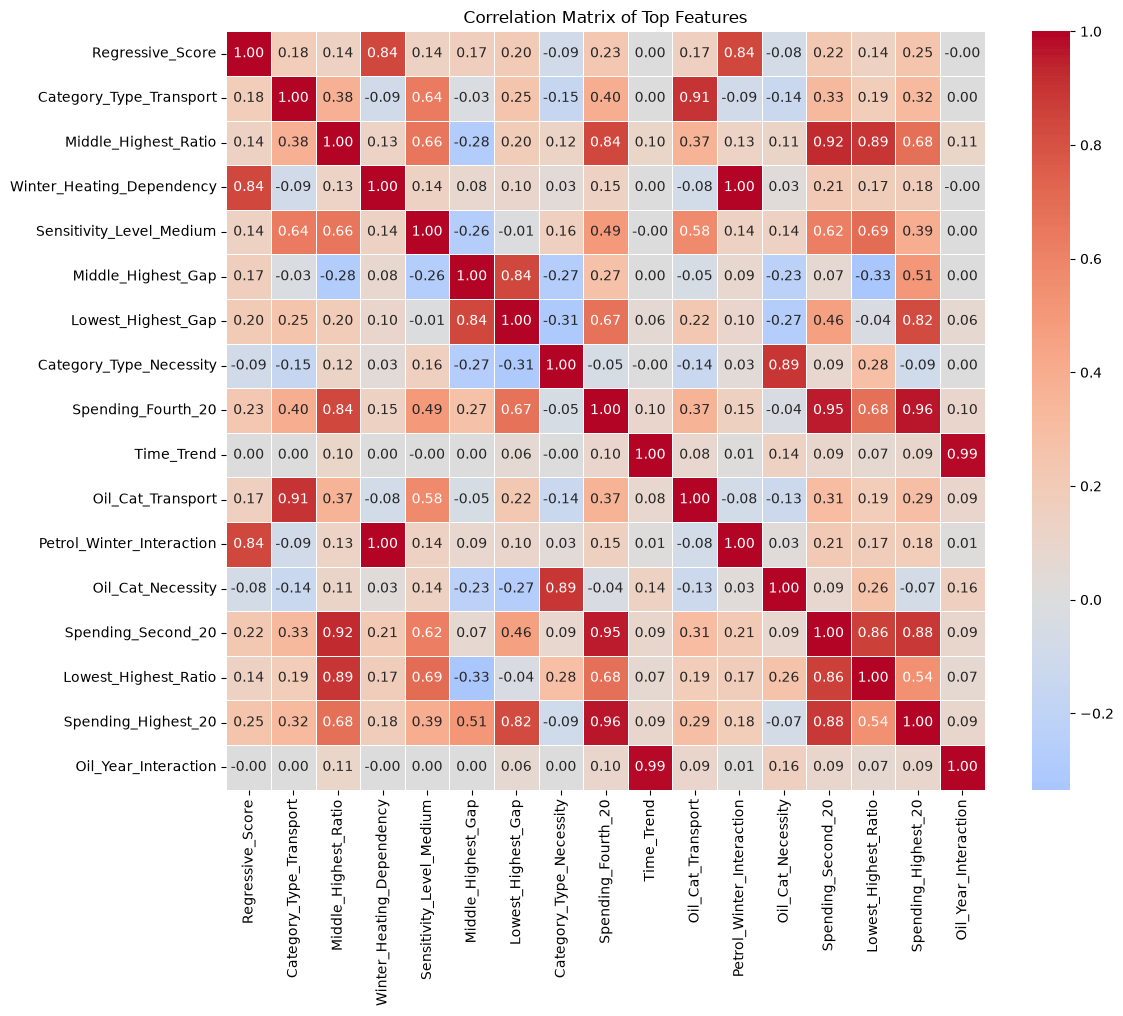

📊 Correlation heatmap saved as 'correlation_matrix.png'

Features with high multicollinearity (corr > 0.8):
Count: 36
Examples: ['Spending_Fourth_20', 'Spending_Highest_20', 'Diesel_Price_pence_per_litre', 'Energy_Crisis', 'Post_COVID', 'Ukraine_War', 'Crude_Lag1', 'Crude_Lag2', 'Crude_Lag3', 'Crude_Rolling_Mean_2Y']

VARIANCE FILTER
Features kept: 49
Features removed: 11

Removed features (low variance):
['CPI_Fuels_and_Lubricants', 'CPI_Electricity', 'CPI_Gas', 'CPI_Liquid_Fuels', 'CPI_Solid_Fuels', 'Oil_Price_Shock', 'Oil_Price_Decline', 'CPI_Energy_Basket', 'CPI_Energy_Std', 'CPI_Gas_Electricity_Ratio']

MUTUAL INFORMATION SELECTION (Spending_Middle_20)
Top 20 features by Mutual Information:
Spending_Second_20           3.119605
Spending_Fourth_20           3.041787
Spending_Highest_20          2.739751
Lowest_Highest_Gap           2.617066
Middle_Highest_Gap           2.372650
Middle_Highest_Ratio         0.932510
Lowest_Highest_Ratio         0.787244
Regressive_Score             

In [29]:
# Run selection for both targets
try:
    print("\n" + "="*60)
    print("FEATURE SELECTION")
    print("="*60)
    
    final_features_low = selector.run_full_selection('Spending_Lowest_20', y_low)
    final_features_mid = selector.run_full_selection('Spending_Middle_20', y_mid)
    
    print("\n✅ Feature selection complete!")
    
except Exception as e:
    print(f"❌ ERROR in feature selection: {str(e)}")
    raise

# CREATE FINAL DATASET

In [30]:
def create_final_dataset(master_fe, selected_features_low, selected_features_mid, X):
   
    try:
        # Get the actual feature names from X (which includes one-hot encoded columns)
        X_feature_names = X.columns.tolist()
        
        # Filter selected features to only those that exist in master_fe or X
        # First, check which features are in master_fe
        master_fe_cols = master_fe.columns.tolist()
        
        # Combine selected features from both targets
        all_selected = list(set(selected_features_low + selected_features_mid))
        
        # Filter to only keep features that exist in master_fe
        # (this excludes one-hot encoded columns that were only in X)
        valid_selected = [col for col in all_selected if col in master_fe_cols]
        
        # Ensure essential features are included (only if they exist in master_fe)
        essential = ['Crude_Oil_Price_USD', 'Petrol_Price_pence_per_litre', 
                    'CPI_Energy_Basket', 'Lowest_Highest_Ratio']
        valid_essential = [col for col in essential if col in master_fe_cols]
        
        # Combine valid features
        final_features = list(set(valid_selected + valid_essential))
        
        # Create final dataset with targets and selected features
        final_cols = ['Year', 'Category'] + target_cols + final_features
        final_df = master_fe[final_cols].copy()
        
        # Drop columns with all zeros or constant values
        final_df = final_df.loc[:, (final_df != 0).any(axis=0)]
        
        print("\n" + "="*60)
        print("FINAL DATASET CREATION")
        print("="*60)
        print(f"Final shape: {final_df.shape}")
        print(f"Features after selection: {len(final_df.columns) - 3}")  # Exclude Year, Category, targets
        print("\nFinal columns:")
        print(final_df.columns.tolist())
        
        # Print warning about excluded one-hot encoded features
        excluded = set(all_selected) - set(final_features)
        if excluded:
            print(f"\n⚠️ Excluded {len(excluded)} one-hot encoded features (not in master_fe):")
            print(list(excluded)[:10])
        
        return final_df
        
    except Exception as e:
        print(f"❌ ERROR in final dataset creation: {str(e)}")
        raise

# Create final dataset - pass X to the function
final_dataset = create_final_dataset(master_fe, final_features_low, final_features_mid, X)


FINAL DATASET CREATION
Final shape: (288, 43)
Features after selection: 40

Final columns:
['Year', 'Category', 'Spending_Lowest_20', 'Spending_Middle_20', 'Winter_Heating_Dependency', 'Crude_Lag1', 'Crude_Volatility', 'Time_Trend', 'Ukraine_War', 'Spending_Highest_20', 'Spending_Second_20_YoY', 'Diesel_Price_pence_per_litre', 'Spending_Highest_20_YoY', 'Crude_Lag2', 'Energy_Crisis', 'Lowest_Highest_Gap', 'Oil_Cat_Transport', 'Fuel_Spread', 'Oil_Cat_Energy', 'Oil_Year_Interaction', 'Crude_Rolling_Mean_3Y', 'Crude_Rolling_Std_2Y', 'Regressive_Score', 'Middle_Highest_Ratio', 'Crude_YoY_Change', 'Middle_Highest_Gap', 'Spending_Fourth_20', 'Spending_Lowest_20_YoY', 'Petrol_Winter_Interaction', 'Crude_Rolling_Std_3Y', 'Petrol_YoY', 'Lowest_Highest_Ratio', 'Oil_Crisis_Interaction', 'Crude_Oil_Price_USD', 'Post_COVID', 'Spending_Middle_20_YoY', 'Petrol_Price_pence_per_litre', 'Crude_Lag3', 'Crude_Rolling_Mean_2Y', 'Spending_Second_20', 'Oil_Cat_Necessity', 'Petrol_Lag1', 'Oil_Cat_Discretiona

# SAVE RESULTS IN MULTIPLE FORMATS

In [31]:
def save_results(final_dataset, master_fe, selector, final_features_low, final_features_mid, feature_cols):
  
    try:
        print("\n" + "="*60)
        print("SAVING RESULTS")
        print("="*60)
        
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        
        # Create directory if it doesn't exist
        import os
        save_dir = '../data/features'
        os.makedirs(save_dir, exist_ok=True)
        print(f"📁 Saving results to: {save_dir}/")
        
        # 6.1 Save CSV files
        print("\n📁 Saving CSV files...")
        master_fe.to_csv(f'{save_dir}/master_dataset_featured.csv', index=False)
        print(f"  ✅ '{save_dir}/master_dataset_featured.csv'")
        
        final_dataset.to_csv(f'{save_dir}/final_selected_dataset.csv', index=False)
        print(f"  ✅ '{save_dir}/final_selected_dataset.csv'")
        
        # 6.2 Save JSON files
        print("\n📁 Saving JSON files...")
        
        # Feature selection summary
        feature_summary = {
            'timestamp': timestamp,
            'total_features_before_selection': len(feature_cols),
            'selected_features_lowest_20_count': len(final_features_low),
            'selected_features_middle_20_count': len(final_features_mid),
            'final_dataset_features_count': len(final_dataset.columns) - 3,
            'selected_features_lowest_20': final_features_low,
            'selected_features_middle_20': final_features_mid,
            'all_selected_features': list(set(final_features_low + final_features_mid)),
            'errors': selector.errors,
            'selection_results': selector.selection_results
        }
        
        with open(f'{save_dir}/feature_selection_summary.json', 'w') as f:
            json.dump(feature_summary, f, indent=4, default=str)
        print(f"  ✅ '{save_dir}/feature_selection_summary.json'")
        
        # Save feature importance separately
        importance_summary = {}
        for key, value in selector.selection_results.items():
            if 'importance' in key or 'correlation' in key or 'mutual_info' in key:
                importance_summary[key] = value
        
        with open(f'{save_dir}/feature_importance.json', 'w') as f:
            json.dump(importance_summary, f, indent=4, default=str)
        print(f"  ✅ '{save_dir}/feature_importance.json'")
        
        # 6.3 Save binary formats
        print("\n📁 Saving binary files...")
        
        # Save using pickle
        with open(f'{save_dir}/selector_object.pkl', 'wb') as f:
            pickle.dump(selector, f)
        print(f"  ✅ '{save_dir}/selector_object.pkl'")
        
        # Save using joblib (if available)
        try:
            import joblib
            joblib.dump(selector, f'{save_dir}/selector_object.joblib')
            print(f"  ✅ '{save_dir}/selector_object.joblib'")
        except ImportError:
            print("  ⚠️ joblib not available, skipping .joblib save")
        
        # Save feature names
        feature_dict = {
            'all_features': feature_cols,
            'selected_features_low': final_features_low,
            'selected_features_mid': final_features_mid,
            'final_dataset_columns': final_dataset.columns.tolist()
        }
        
        with open(f'{save_dir}/feature_names.pkl', 'wb') as f:
            pickle.dump(feature_dict, f)
        print(f"  ✅ '{save_dir}/feature_names.pkl'")
        
        # 6.4 Save error log if any
        if selector.errors:
            print("\n📁 Saving error log...")
            with open(f'{save_dir}/feature_selection_errors.json', 'w') as f:
                json.dump(selector.errors, f, indent=4)
            print(f"  ✅ '{save_dir}/feature_selection_errors.json'")
        
        # 6.5 Save as parquet (if available)
        try:
            import pyarrow
            final_dataset.to_parquet(f'{save_dir}/final_selected_dataset.parquet')
            master_fe.to_parquet(f'{save_dir}/master_dataset_featured.parquet')
            print("\n📁 Saving Parquet files...")
            print(f"  ✅ '{save_dir}/final_selected_dataset.parquet'")
            print(f"  ✅ '{save_dir}/master_dataset_featured.parquet'")
        except ImportError:
            print("\n  ⚠️ pyarrow not available, skipping parquet save")
        
        print("\n✅ All results saved successfully!")
        print(f"📂 All files saved in: {save_dir}/")
        
    except Exception as e:
        print(f"❌ ERROR in saving results: {str(e)}")
        raise

# Save all results
save_results(final_dataset, master_fe, selector, final_features_low, final_features_mid, feature_cols)


SAVING RESULTS
📁 Saving results to: ../data/features/

📁 Saving CSV files...
  ✅ '../data/features/master_dataset_featured.csv'
  ✅ '../data/features/final_selected_dataset.csv'

📁 Saving JSON files...
  ✅ '../data/features/feature_selection_summary.json'
  ✅ '../data/features/feature_importance.json'

📁 Saving binary files...
  ✅ '../data/features/selector_object.pkl'
  ✅ '../data/features/selector_object.joblib'
  ✅ '../data/features/feature_names.pkl'



📁 Saving Parquet files...
  ✅ '../data/features/final_selected_dataset.parquet'
  ✅ '../data/features/master_dataset_featured.parquet'

✅ All results saved successfully!
📂 All files saved in: ../data/features/


# DATA QUALITY REPORT

In [32]:
print("\n" + "="*60)
print("DATA QUALITY REPORT")
print("="*60)

try:
    print(f"\n1. Dataset shape: {final_dataset.shape}")
    print(f"\n2. Missing values in final dataset: {final_dataset.isnull().sum().sum()}")
    print(f"\n3. Data types:")
    print(final_dataset.dtypes.value_counts())
    
    print("\n4. Basic statistics of final selected features:")
    print(final_dataset.describe())
    
    # Check for any remaining issues
    print("\n5. Feature correlations with targets:")
    for target in target_cols:
        correlations = final_dataset.corrwith(final_dataset[target]).sort_values(ascending=False)
        print(f"\nTop 5 features correlated with {target}:")
        print(correlations.head(5))
    
    print("\n6. Summary of feature selection:")
    print(f"   - Original features: {len(feature_cols)}")
    print(f"   - Selected for Lowest_20: {len(final_features_low)}")
    print(f"   - Selected for Middle_20: {len(final_features_mid)}")
    print(f"   - Final dataset features: {len(final_dataset.columns) - 3}")
    
    # Error summary
    if selector.errors:
        print("\n7. ⚠️ Errors encountered during feature selection:")
        for step, error in selector.errors.items():
            print(f"   - {step}: {error}")
    else:
        print("\n7. ✅ No errors encountered during feature selection")
    
    print("\n" + "="*60)
    print("✅ FEATURE ENGINEERING AND SELECTION COMPLETE!")
    print("="*60)
    
except Exception as e:
    print(f"❌ ERROR in data quality report: {str(e)}")


DATA QUALITY REPORT

1. Dataset shape: (288, 43)

2. Missing values in final dataset: 0

3. Data types:
float64    36
int64       6
object      1
Name: count, dtype: int64

4. Basic statistics of final selected features:
              Year  Spending_Lowest_20  Spending_Middle_20  \
count   288.000000          288.000000          288.000000   
mean   2022.500000            4.886536            8.511892   
std       1.710798            5.043851            7.195757   
min    2020.000000            0.290000            0.560000   
25%    2021.000000            1.807500            3.447500   
50%    2022.500000            2.805000            5.315000   
75%    2024.000000            5.967500           11.185000   
max    2025.000000           25.892500           25.892500   

       Winter_Heating_Dependency  Crude_Lag1  Crude_Volatility  Time_Trend  \
count                 288.000000  288.000000        288.000000  288.000000   
mean                    0.083333  373.245085          0.029333 